# Telco Customer Churn Analysis

## Business Problem

Customer churn is a major challenge for subscription-based businesses. Losing customers reduces recurring revenue and increases customer acquisition costs.

The objective of this project is to identify the factors associated with customer churn, build predictive models to identify high-risk customers, and provide business recommendations to improve customer retention.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "C:/Users/Admin/Documents/Churn Customer Analysis/Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

In [9]:
df["TotalCharges"].isnull().sum()

11

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df = df.dropna()

In [17]:
df.isnull().sum().sum()

0

In [19]:
df.duplicated().sum()

0

In [21]:
df["customerID"].nunique()

7032

In [23]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [25]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


<Axes: >

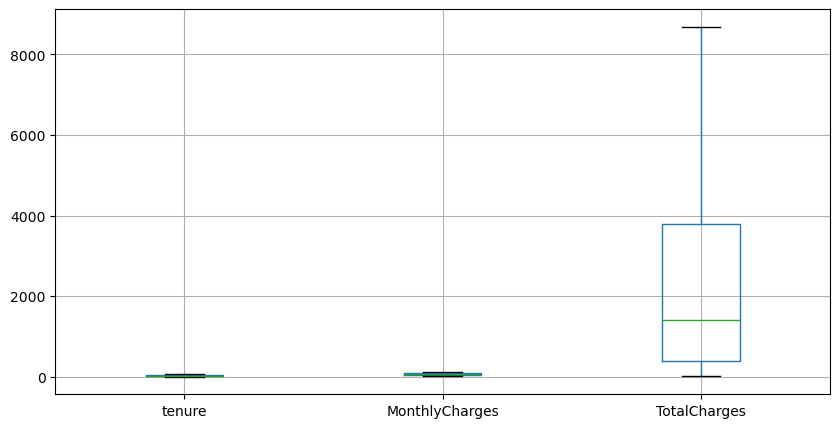

In [27]:
num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[num_cols].boxplot(figsize=(10,5))

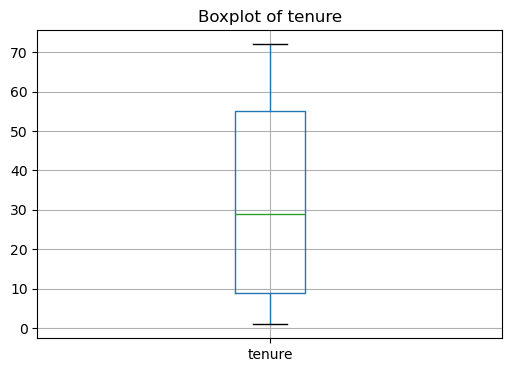

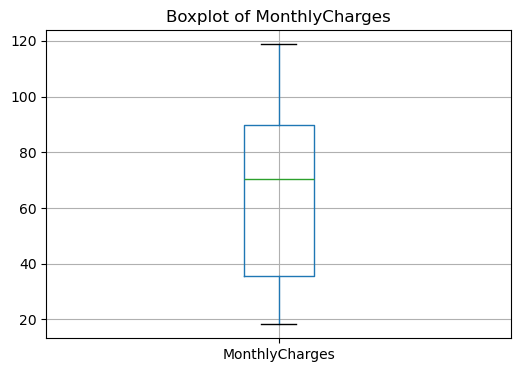

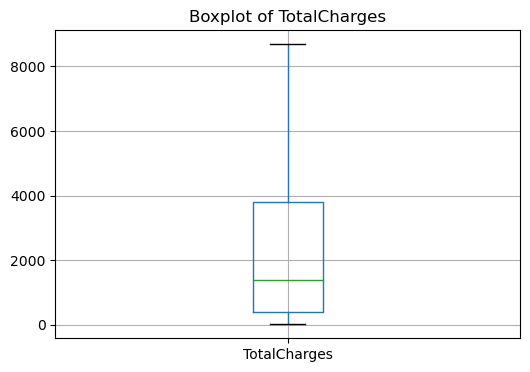

In [29]:
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [31]:
df["SeniorCitizen"] = df["SeniorCitizen"].map(
    {0:"No", 1:"Yes"}
)

In [33]:
df.to_csv(
    "telco_churn_clean.csv",
    index=False
)

## Exploratory Data Analysis

In [36]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [38]:
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(churn_pct)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


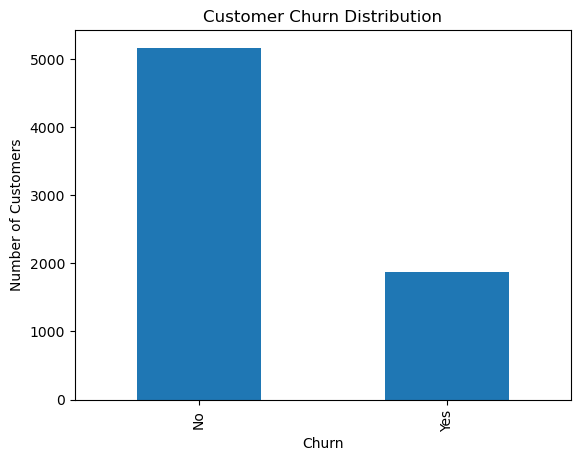

In [40]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

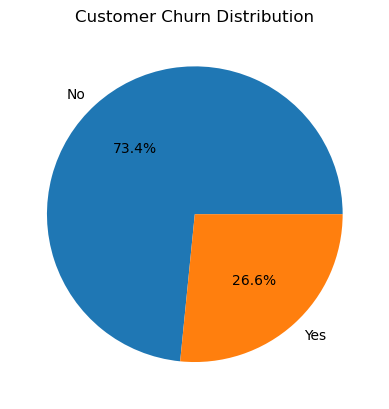

In [42]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

In [44]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [46]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


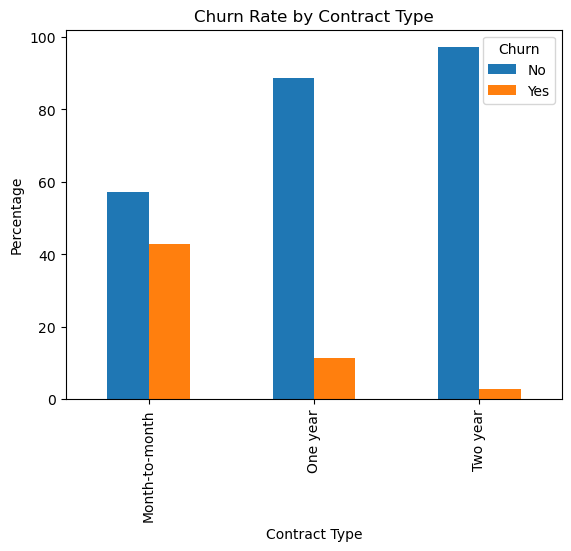

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

In [50]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [52]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


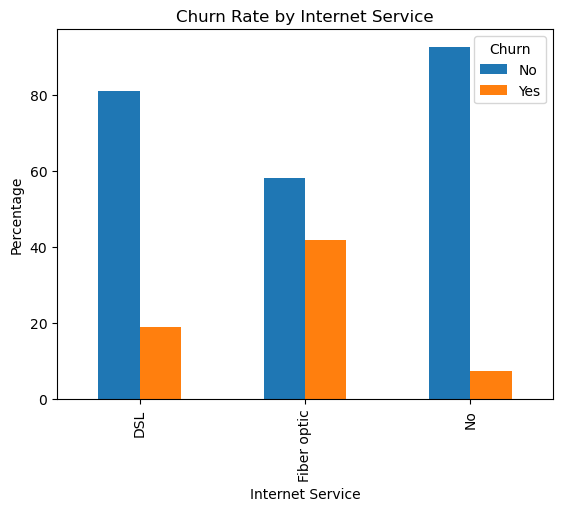

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

In [56]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [58]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


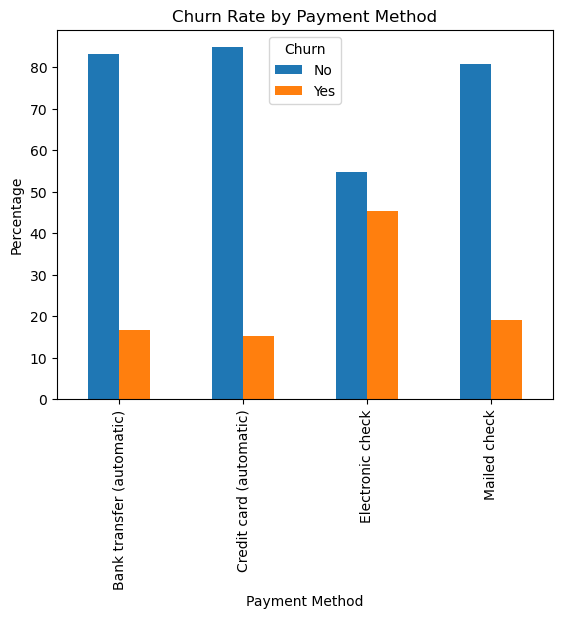

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

In [62]:
pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,No,Yes
SeniorCitizen,,
No,4497,1393
Yes,666,476


In [64]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
No,76.349745,23.650255
Yes,58.318739,41.681261


<Figure size 800x500 with 0 Axes>

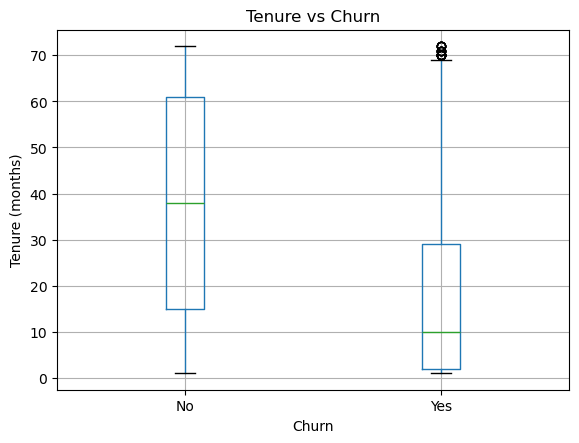

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.boxplot(column="tenure", by="Churn")
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

In [68]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [70]:
pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TenureGroup,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


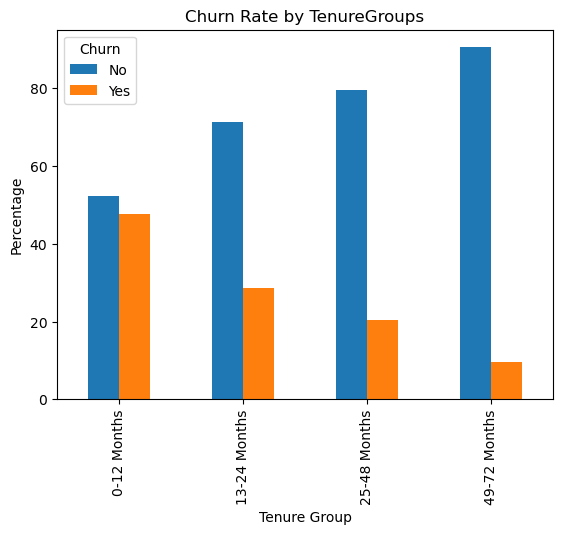

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

group_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

group_churn.plot(kind="bar")

plt.title("Churn Rate by TenureGroups")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

## Correlation Analysis

In [75]:
df_corr = df.copy()

df_corr["Churn"] = df_corr["Churn"].map({
    "No": 0,
    "Yes": 1
})

df_corr["SeniorCitizen"] = df_corr["SeniorCitizen"].map({
    "No": 0,
    "Yes": 1
})

corr = df_corr[
    ["SeniorCitizen",
     "tenure",
     "MonthlyCharges",
     "TotalCharges",
     "Churn"]
].corr()

corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150541,-0.354049,0.192858,-0.199484,1.000000


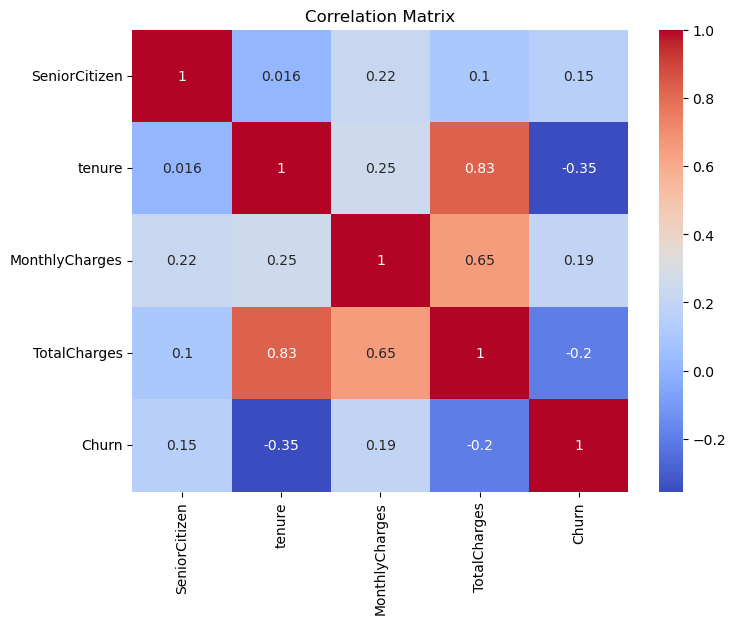

In [77]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Predictive Modeling

In [80]:
df_model = df.copy()

df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})

df_model = df_model.drop("customerID", axis=1)

X = pd.get_dummies(
    df_model.drop("Churn", axis=1),
    drop_first=True
)

y = df_model["Churn"]

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [94]:
y_pred = model.predict(X_test_scaled)

In [96]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7938877043354655


In [98]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[919 114]
 [176 198]]


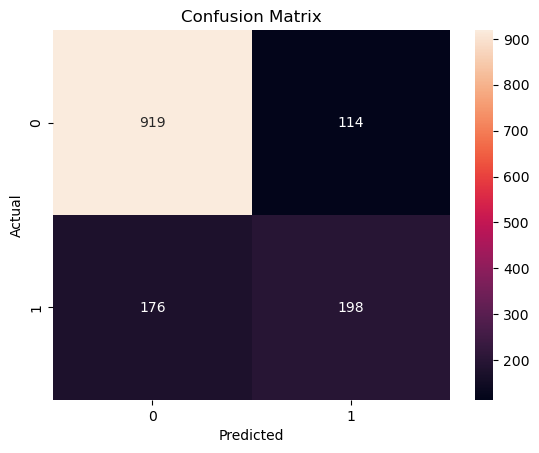

In [100]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [102]:
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

[[919 114]
 [176 198]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [104]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(feature_importance.head(15))
print(feature_importance.tail(15))

                                  Feature  Coefficient
10            InternetService_Fiber optic     0.703264
2                            TotalCharges     0.309320
21                        StreamingTV_Yes     0.250505
23                    StreamingMovies_Yes     0.233280
9                       MultipleLines_Yes     0.228524
32               TenureGroup_49-72 Months     0.226413
28         PaymentMethod_Electronic check     0.176526
26                   PaperlessBilling_Yes     0.144099
17                   DeviceProtection_Yes     0.079483
4                       SeniorCitizen_Yes     0.075494
29             PaymentMethod_Mailed check     0.029664
27  PaymentMethod_Credit card (automatic)     0.024508
8          MultipleLines_No phone service     0.019446
5                             Partner_Yes    -0.007266
3                             gender_Male    -0.012177
                                 Feature  Coefficient
20       StreamingTV_No internet service    -0.081216
22   Streami

## XGBoost Model

In [107]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [109]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

cm_xgb = confusion_matrix(y_test, xgb_pred)
print("\nConfusion Matrix:")
print(cm_xgb)

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.7945984363894811

Confusion Matrix:
[[919 114]
 [175 199]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



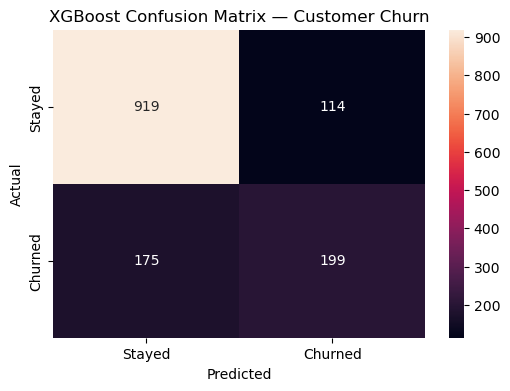

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("XGBoost Confusion Matrix — Customer Churn")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [113]:
df.to_csv(
    r"C:\Users\Admin\Documents\Churn Customer Analysis\telco_churn_clean.csv",
    index=False
)

## Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Improve onboarding during the first 12 months of service.
2. Encourage month-to-month customers to switch to annual contracts.
3. Offer incentives for customers using Electronic Check to adopt automatic payment methods.
4. Review pricing and service quality for Fiber Optic customers.
5. Develop targeted retention campaigns for senior customers.